# RNN/LSTM Scratch Pipeline

End-to-end pipeline: raw image -> CNN feature -> scratch decoder -> caption.

In [1]:
import sys, os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input

# Add repo root to path
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from src.captioning.preprocessing import load_vocab
from src.rnn.model import CaptioningModelScratch

print('TF version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

I0000 00:00:1778850610.701779   79077 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778850613.760157   79077 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778850655.447519   79077 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TF version: 2.21.0
GPU: []


E0000 00:00:1778850683.669736   79077 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1778850683.687928   79222 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1778850683.861856   79077 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [ ]:
# Keras compatibility: strip quantization_config from .keras config
import json
import zipfile
import tempfile
import shutil

def _strip_key(obj, key):
    if isinstance(obj, dict):
        if key in obj:
            obj.pop(key, None)
        for v in obj.values():
            _strip_key(v, key)
    elif isinstance(obj, list):
        for item in obj:
            _strip_key(item, key)

def load_model_safe(path):
    tmpdir = tempfile.mkdtemp(prefix='keras_model_')
    try:
        with zipfile.ZipFile(path, 'r') as zf:
            zf.extractall(tmpdir)
        config_path = os.path.join(tmpdir, 'config.json')
        with open(config_path, 'r', encoding='utf-8') as f:
            config = json.load(f)
        _strip_key(config, 'quantization_config')
        with open(config_path, 'w', encoding='utf-8') as f:
            json.dump(config, f)
        return keras.models.load_model(tmpdir, compile=False, safe_mode=False)
    finally:
        shutil.rmtree(tmpdir, ignore_errors=True)

In [8]:
ROOT

PosixPath('/mnt/c/Users/User/Documents/ITB/ML/CNN/MLYuk2')

In [9]:
# Paths
VOCAB_FILE = ROOT / 'data/flickr8k/vocab.json'
MODEL_DIR  = ROOT / 'models/rnn'
IMAGE_DIR  = ROOT / 'data/flickr8k/Images'

# Pick decoder config
DECODER_TYPE = 'rnn'  # 'rnn' or 'lstm'
NUM_LAYERS   = 2
HIDDEN       = 128
CFG_NAME     = f'{DECODER_TYPE}_L{NUM_LAYERS}_H{HIDDEN}'
MODEL_PATH   = MODEL_DIR / f'{CFG_NAME}.keras'

# Pick an image
image_paths = sorted(IMAGE_DIR.glob('*.jpg'))
if not image_paths:
    raise FileNotFoundError(f'No .jpg files found in {IMAGE_DIR}')
IMG_PATH = image_paths[0]

print('Model:', MODEL_PATH)
print('Image:', IMG_PATH.name)

Model: /mnt/c/Users/User/Documents/ITB/ML/CNN/MLYuk2/models/rnn/rnn_L2_H128.keras
Image: foto-13523030.jpg


In [10]:
# Build CNN encoder and extract feature
encoder = InceptionV3(include_top=False, weights='imagenet', pooling='avg')

img = keras.utils.load_img(IMG_PATH, target_size=(299, 299))
arr = keras.utils.img_to_array(img)
arr = np.expand_dims(arr, axis=0)
arr = preprocess_input(arr)

feat = encoder.predict(arr, verbose=0)[0]  # (2048,)

In [15]:
# Load vocab and scratch decoder
word2idx, idx2word = load_vocab(VOCAB_FILE)

keras_model = load_model_safe(MODEL_PATH)
scratch = CaptioningModelScratch(
    keras_model,
    word2idx,
    idx2word,
    decoder_type=DECODER_TYPE,
    num_rnn_layers=NUM_LAYERS
)

caption = scratch.generate_caption(feat, max_len=35)
print('Caption:', caption)

TypeError: <class 'keras.src.models.functional.Functional'> could not be deserialized properly. Please ensure that components that are Python object instances (layers, models, etc.) returned by `get_config()` are explicitly deserialized in the model's `from_config()` method.

config={'module': 'keras.src.models.functional', 'class_name': 'Functional', 'config': {}, 'registered_name': 'Functional', 'build_config': {'input_shape': None}, 'compile_config': None}.

Exception encountered: <class 'keras.src.layers.core.embedding.Embedding'> could not be deserialized properly. Please ensure that components that are Python object instances (layers, models, etc.) returned by `get_config()` are explicitly deserialized in the model's `from_config()` method.

config={'module': 'keras.layers', 'class_name': 'Embedding', 'config': {'name': 'embedding', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None, 'shared_object_i

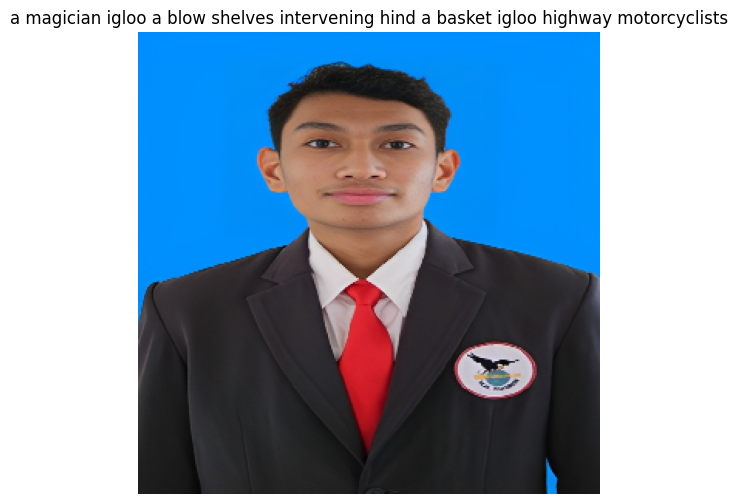

In [ ]:
# Show image with caption
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')
plt.title(caption)
plt.show()